Lattice Shape: (21, 21, 21)
Data matches: False
Differences detected in data.


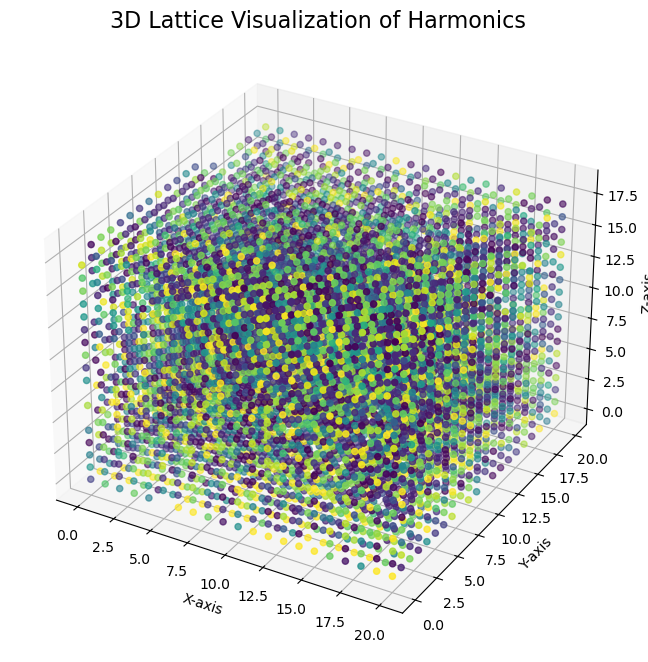

Original Data (First 10 Bytes): [ 49 185 115 195 110   0 255 255 195  12]
Retrieved Data (First 10 Bytes): [ 49 134 111   3 102   0 221   0 128  40]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants
HARMONIC_CONSTANT = 0.35
TOLERANCE = 0.01
EXPANSION_FACTOR = 1.5
MAX_ITERATIONS = 100

# Step 1: Encode Data into H using a Lattice Structure
def store_in_lattice(binary_data, harmonic_constant=HARMONIC_CONSTANT):
    """
    Store binary data into a 3D lattice using harmonic properties.
    """
    # Normalize binary data to [0, 1]
    normalized_data = binary_data / 255.0
    
    # Create a 3D lattice
    lattice_size = int(np.cbrt(len(normalized_data))) + 1  # Ensure enough space
    lattice = np.zeros((lattice_size, lattice_size, lattice_size), dtype=np.float64)
    
    # Map data into lattice positions
    for idx, value in enumerate(normalized_data):
        x, y, z = idx % lattice_size, (idx // lattice_size) % lattice_size, idx // (lattice_size ** 2)
        lattice[x, y, z] += value * harmonic_constant  # Add harmonic scaling

    return lattice

# Step 2: Retrieve Data from Lattice
def retrieve_from_lattice(lattice, harmonic_constant=HARMONIC_CONSTANT):
    """
    Retrieve binary data from a 3D lattice.
    """
    flattened_data = lattice.flatten() / harmonic_constant
    return np.round(flattened_data * 255).astype(np.uint8)  # Scale back to original range

# Step 3: Visualize the Lattice
def visualize_lattice(lattice):
    """
    Create a 3D scatter plot of the lattice points.
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    x, y, z = np.nonzero(lattice)
    values = lattice[x, y, z]
    
    # Plot the lattice points
    ax.scatter(x, y, z, c=values, cmap='viridis', s=20)
    ax.set_title("3D Lattice Visualization of Harmonics", fontsize=16)
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")
    ax.set_zlabel("Z-axis")
    plt.show()

# Test the Lattice-Based Compression
if __name__ == "__main__":
    # Load binary data (example: BIOS file)
    with open(r'd:\colecovision.rom', 'rb') as file:
        binary_data = np.frombuffer(file.read(), dtype=np.uint8)  # Read binary as bytes

    # Step 1: Store Data in Lattice
    harmonic_lattice = store_in_lattice(binary_data, HARMONIC_CONSTANT)
    print("Lattice Shape:", harmonic_lattice.shape)

    # Step 2: Retrieve Data from Lattice
    retrieved_data = retrieve_from_lattice(harmonic_lattice, HARMONIC_CONSTANT)
    
    # Validate the process
    is_equal = np.array_equal(binary_data, retrieved_data)
    print("Data matches:", is_equal)
    if not is_equal:
        print("Differences detected in data.")

    # Step 3: Visualize the Lattice
    visualize_lattice(harmonic_lattice)

    # Print a sample of the data
    print("Original Data (First 10 Bytes):", binary_data[:10])
    print("Retrieved Data (First 10 Bytes):", retrieved_data[:10])


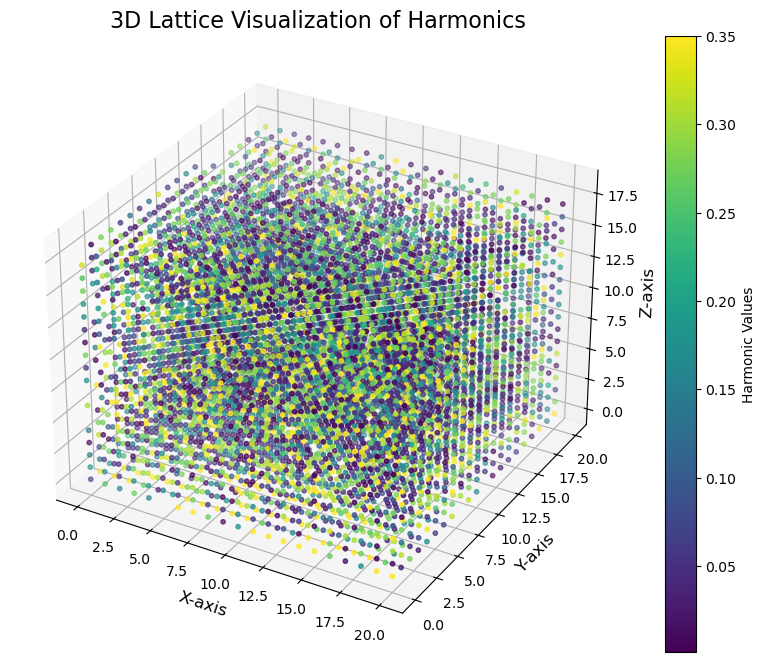

Lattice Shape: (21, 21, 21)
Original Data (First 10 Bytes): [ 49 185 115 195 110   0 255 255 195  12]
Retrieved Data (First 10 Bytes): [ 49 134 111   3 102   0 221   0 128  40]
Data matches: False
Differences detected in data.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants
HARMONIC_CONSTANT = 0.35  # Scaling factor for harmonics

# Step 1: Encode Data into a 3D Lattice
def store_in_lattice(binary_data, harmonic_constant=HARMONIC_CONSTANT):
    """
    Store binary data into a 3D lattice using harmonic properties.
    """
    normalized_data = binary_data / 255.0  # Normalize binary data to [0, 1]
    
    # Create a 3D lattice
    lattice_size = int(np.cbrt(len(normalized_data))) + 1  # Ensure enough space
    lattice = np.zeros((lattice_size, lattice_size, lattice_size), dtype=np.float64)
    
    # Map data into lattice positions
    for idx, value in enumerate(normalized_data):
        x, y, z = idx % lattice_size, (idx // lattice_size) % lattice_size, idx // (lattice_size ** 2)
        lattice[x, y, z] += value * harmonic_constant  # Add harmonic scaling

    return lattice

# Step 2: Retrieve Data from the 3D Lattice
def retrieve_from_lattice(lattice, harmonic_constant=HARMONIC_CONSTANT):
    """
    Retrieve binary data from a 3D lattice.
    """
    flattened_data = lattice.flatten() / harmonic_constant  # Scale back by harmonic constant
    return np.round(flattened_data * 255).astype(np.uint8)  # Ensure integer byte output

# Visualization of the 3D Lattice
def visualize_lattice(lattice):
    """
    Visualize the 3D harmonic lattice.
    """
    x, y, z = np.nonzero(lattice)  # Get non-zero positions
    values = lattice[x, y, z]  # Corresponding harmonic values
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x, y, z, c=values, cmap='viridis', s=10)

    # Add labels and title
    ax.set_title("3D Lattice Visualization of Harmonics", fontsize=16)
    ax.set_xlabel("X-axis", fontsize=12)
    ax.set_ylabel("Y-axis", fontsize=12)
    ax.set_zlabel("Z-axis", fontsize=12)
    plt.colorbar(scatter, ax=ax, label="Harmonic Values")
    plt.show()

# Main Execution
if __name__ == "__main__":
    # Load binary bits from your file
    with open(r'd:\\colecovision.rom', 'rb') as file:
        binary_data = np.frombuffer(file.read(), dtype=np.uint8)  # Read binary as bytes

    # Store binary data in harmonic lattice
    lattice = store_in_lattice(binary_data)

    # Retrieve binary data from the harmonic lattice
    retrieved_data = retrieve_from_lattice(lattice)

    # Visualize the harmonic lattice
    visualize_lattice(lattice)

    # Outputs: Compare Original and Retrieved Data
    print("Lattice Shape:", lattice.shape)
    print("Original Data (First 10 Bytes):", binary_data[:10])
    print("Retrieved Data (First 10 Bytes):", retrieved_data[:10])
    
    # Validate if original and retrieved data match
    data_matches = np.array_equal(binary_data, retrieved_data)
    print("Data matches:", data_matches)
    if not data_matches:
        print("Differences detected in data.")


Iteration 1


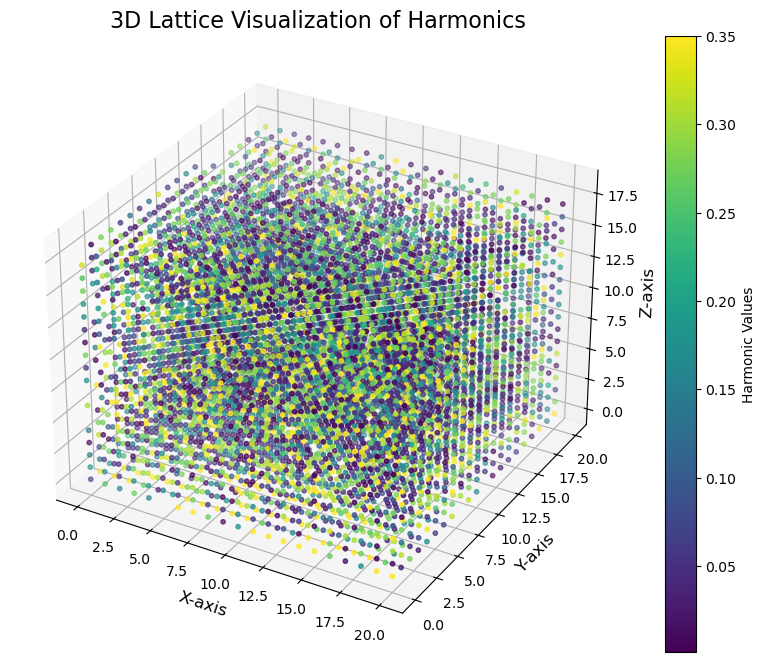

Lattice Shape: (21, 21, 21)
Original Data (First 10 Bytes): [ 48 133 110   2 101   0 220   0 127  39]
Retrieved Data (First 10 Bytes): [ 49 134 111   3 102   0 221   0 128  40]
Data matches: False
Differences detected in data.
Iteration 2


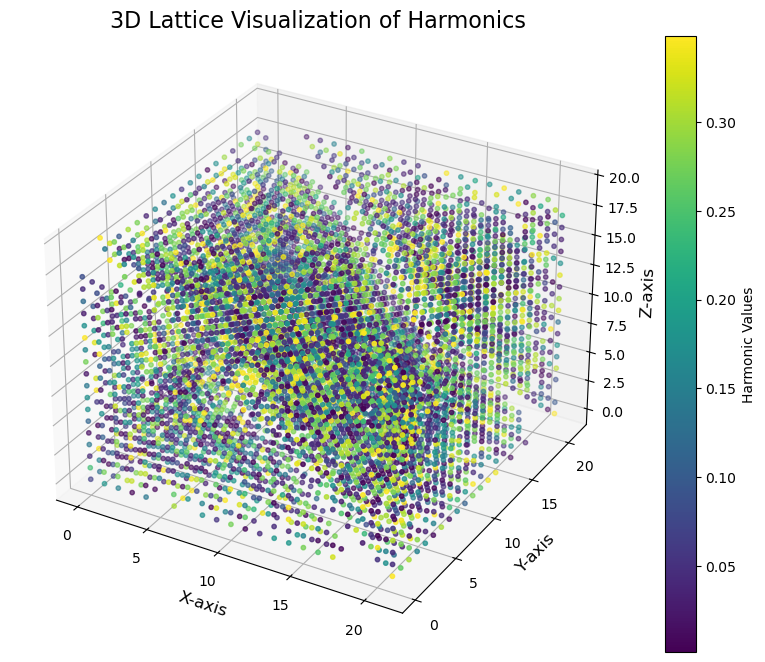

Lattice Shape: (22, 22, 22)
Original Data (First 10 Bytes): [ 53 180  34 107  15  88 132 132 106  19]
Retrieved Data (First 10 Bytes): [ 48 175  29 102  10  83 127 127 101  14]
Data matches: False
Differences detected in data.
Iteration 3


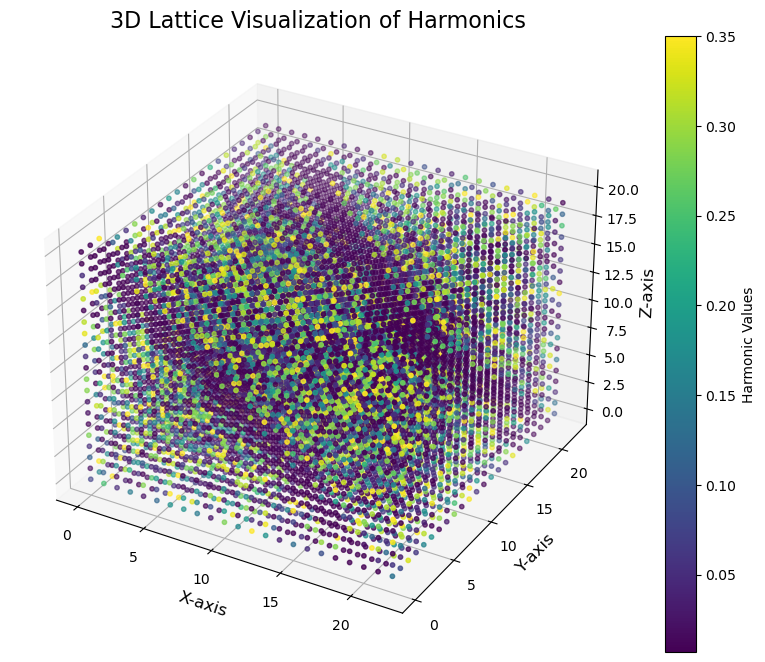

Lattice Shape: (23, 23, 23)
Original Data (First 10 Bytes): [ 61  20  90  44 213  13  22  26 217 215]
Retrieved Data (First 10 Bytes): [ 53  12  82  36 205   5  14  18 209 207]
Data matches: False
Differences detected in data.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants
HARMONIC_CONSTANT = 0.35  # Scaling factor for harmonics
ITERATIONS = 3  # Number of feedback loop iterations

# Step 1: Encode Data into a 3D Lattice
def store_in_lattice(binary_data, harmonic_constant=HARMONIC_CONSTANT):
    """
    Store binary data into a 3D lattice using harmonic properties.
    """
    normalized_data = binary_data / 255.0  # Normalize binary data to [0, 1]
    
    # Create a 3D lattice
    lattice_size = int(np.cbrt(len(normalized_data))) + 1  # Ensure enough space
    lattice = np.zeros((lattice_size, lattice_size, lattice_size), dtype=np.float64)
    
    # Map data into lattice positions
    for idx, value in enumerate(normalized_data):
        x, y, z = idx % lattice_size, (idx // lattice_size) % lattice_size, idx // (lattice_size ** 2)
        lattice[x, y, z] += value * harmonic_constant  # Add harmonic scaling

    return lattice

# Step 2: Retrieve Data from the 3D Lattice
def retrieve_from_lattice(lattice, harmonic_constant=HARMONIC_CONSTANT):
    """
    Retrieve binary data from a 3D lattice.
    """
    flattened_data = lattice.flatten() / harmonic_constant  # Scale back by harmonic constant
    return np.round(flattened_data * 255).astype(np.uint8)  # Ensure integer byte output

# Step 3: Harmonic Compression for Feedback Loop
def harmonize_data(data, harmonic_constant=HARMONIC_CONSTANT):
    """
    Adjust data to harmonize values closer to the harmonic constant.
    """
    delta = np.mean(data) - harmonic_constant  # Difference from harmonic constant
    adjustment = delta * 0.5  # Gain factor for correction
    data = np.clip(data - adjustment, 0, 1)  # Adjust and clip values to binary range
    return data

# Visualization of the 3D Lattice
def visualize_lattice(lattice):
    """
    Visualize the 3D harmonic lattice.
    """
    x, y, z = np.nonzero(lattice)  # Get non-zero positions
    values = lattice[x, y, z]  # Corresponding harmonic values
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x, y, z, c=values, cmap='viridis', s=10)

    # Add labels and title
    ax.set_title("3D Lattice Visualization of Harmonics", fontsize=16)
    ax.set_xlabel("X-axis", fontsize=12)
    ax.set_ylabel("Y-axis", fontsize=12)
    ax.set_zlabel("Z-axis", fontsize=12)
    plt.colorbar(scatter, ax=ax, label="Harmonic Values")
    plt.show()

# Main Execution
if __name__ == "__main__":
    # Load binary bits from your file
    with open(r'd:\\colecovision.rom', 'rb') as file:
        binary_data = np.frombuffer(file.read(), dtype=np.uint8)  # Read binary as bytes

    # Feedback loop
    for iteration in range(ITERATIONS):
        print(f"Iteration {iteration + 1}")
        
        # Store binary data in harmonic lattice
        lattice = store_in_lattice(binary_data)
        
        # Visualize the harmonic lattice
        visualize_lattice(lattice)
        
        # Retrieve binary data from the harmonic lattice
        retrieved_data = retrieve_from_lattice(lattice)

        # Adjust harmonics for feedback
        harmonized_data = harmonize_data(retrieved_data / 255.0)
        binary_data = (harmonized_data * 255).astype(np.uint8)  # Update for next iteration

        # Outputs: Compare Original and Retrieved Data
        print("Lattice Shape:", lattice.shape)
        print("Original Data (First 10 Bytes):", binary_data[:10])
        print("Retrieved Data (First 10 Bytes):", retrieved_data[:10])
        
        # Validate if original and retrieved data match
        data_matches = np.array_equal(binary_data, retrieved_data)
        print("Data matches:", data_matches)
        if not data_matches:
            print("Differences detected in data.")


In [ ]:
from tqdm import tqdm
import wave
import numpy as np

# Constants
HARMONIC_CONSTANT = 0.35
TOLERANCE = 0.01
MAX_ITERATIONS = 100

# 1. Read WAV File
def read_wav_file(filename):
    """Reads a .wav file and extracts audio data."""
    with wave.open(filename, 'rb') as wav_file:
        n_channels = wav_file.getnchannels()
        sample_width = wav_file.getsampwidth()
        framerate = wav_file.getframerate()
        n_frames = wav_file.getnframes()

        # Extract raw audio data
        raw_data = wav_file.readframes(n_frames)
        
        # Convert bytes to integer data
        dtype = np.int16 if sample_width == 2 else np.int8
        audio_data = np.frombuffer(raw_data, dtype=dtype)
        
        return audio_data, n_channels, sample_width, framerate

# 2. Save WAV File
def save_wav_file(filename, audio_data, n_channels, sample_width, framerate):
    """Saves audio data back to a .wav file."""
    with wave.open(filename, 'wb') as wav_file:
        wav_file.setnchannels(n_channels)
        wav_file.setsampwidth(sample_width)
        wav_file.setframerate(framerate)

        # Convert integer data to bytes and write
        wav_file.writeframes(audio_data.tobytes())

# 3. Convert Audio to Binary with Progress Meter
def audio_to_binary(audio_data):
    """Converts signed audio data to binary string with progress tracking."""
    max_bits = 16 if audio_data.dtype == np.int16 else 8
    binary_data = ''.join(
        format(sample & (2**max_bits - 1), f'0{max_bits}b') 
        for sample in tqdm(audio_data, desc="Converting audio to binary")
    )
    return binary_data

# 4. Convert Binary to Matrix with Progress Meter
def binary_to_matrix(binary_data):
    """Converts binary data to a 2D matrix with progress tracking."""
    binary_length = len(binary_data)
    matrix_size = int(np.ceil(np.sqrt(binary_length)))
    data_matrix = np.zeros((matrix_size, matrix_size), dtype=np.float64)

    for i, bit in tqdm(enumerate(binary_data), total=binary_length, desc="Filling matrix"):
        data_matrix[i // matrix_size, i % matrix_size] = int(bit)

    return data_matrix

# 5. Harmonize Data with Progress Meter
def harmonize_data(data, harmonic_constant, compress=True):
    """Compress or expand data by aligning it with the harmonic constant, with progress tracking."""
    data = np.copy(data)
    gain = 1.0 if compress else -1.0

    for iteration in tqdm(range(MAX_ITERATIONS), desc="Harmonic adjustment"):
        delta = np.mean(data) - harmonic_constant
        adjustment = delta * gain
        data -= adjustment
        data = np.clip(data, 0, 1)  # Ensure binary range
        if abs(delta) < TOLERANCE:
            break

    return data

# 6. Binary to Audio
def binary_to_audio(binary_data, dtype):
    """Converts binary string back to signed audio data."""
    max_bits = 16 if dtype == np.int16 else 8
    num_samples = len(binary_data) // max_bits
    audio_data = []

    for i in range(num_samples):
        value = int(binary_data[i * max_bits:(i + 1) * max_bits], 2)
        # Convert from two's complement if necessary
        if value >= 2**(max_bits - 1):
            value -= 2**max_bits
        audio_data.append(value)

    return np.array(audio_data, dtype=dtype)

# Main Workflow
if __name__ == "__main__":
    # Input and Output Files
    input_wav_file = "d:\\test.wav"
    compressed_file = "d:\\compressed_audio.npz"
    output_wav_file = "d:\\restored.wav"

    # Step 1: Read the Input WAV File
    audio_data, n_channels, sample_width, framerate = read_wav_file(input_wav_file)
    print(f"Read WAV File: {input_wav_file}")
    print(f"Channels: {n_channels}, Sample Width: {sample_width}, Frame Rate: {framerate}")

    # Step 2: Convert Audio to Binary
    binary_data = audio_to_binary(audio_data)

    # Step 3: Convert Binary to Matrix
    data_matrix = binary_to_matrix(binary_data)

    # Step 4: Apply Harmonic Compression
    compressed_data = harmonize_data(data_matrix, HARMONIC_CONSTANT, compress=True)
    print("Compressed Data Non-Zero Elements:", np.count_nonzero(compressed_data))

    # Step 5: Save Compressed Data
    np.savez_compressed(compressed_file, compressed_matrix=compressed_data)
    print(f"Compressed data saved to {compressed_file}")

    # Step 6: Load Compressed Data and Expand
    loaded_data = np.load(compressed_file)['compressed_matrix']
    expanded_data = harmonize_data(loaded_data, HARMONIC_CONSTANT, compress=False)

    # Step 7: Flatten Expanded Data and Convert Back to Audio
    flattened_binary = ''.join(str(int(round(bit))) for bit in tqdm(expanded_data.flatten(), desc="Flattening matrix"))
    restored_audio = binary_to_audio(flattened_binary, audio_data.dtype)

    # Step 8: Save Restored Audio to a New WAV File
    save_wav_file(output_wav_file, restored_audio, n_channels, sample_width, framerate)
    print(f"Restored WAV File Saved: {output_wav_file}")


Read WAV File: d:\test.wav
Channels: 2, Sample Width: 2, Frame Rate: 44100


Converting audio to binary:  82%|████████▏ | 16764181/20494152 [01:10<00:15, 241991.89it/s]